## **Evaluating Strategy built rom Regression model**

In [1]:
import statsmodels.formula.api as smf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
indicepanel = pd.read_csv('data/indice/indicepanel.csv')
indicepanel.head()

,Unnamed: 0,spy,spy_lag1,sp500,nasdaq,dji,cac40,daxi,aord,hsi,nikkei,Price
0,1,-1.570008,-1.619995,-20.419922,-41.949951,-217.70019,-71.779785,-104.450195,4.100097,-582.169922,-606.350586,144.910004
1,2,-1.529998,-1.570008,-3.540039,-40.879883,2.43945,5.489746,-27.990235,-35.000000,-45.689453,-120.080078,143.339996
2,3,0.270004,-1.529998,-29.940064,-56.930176,-245.40918,-111.689941,-102.709961,-29.900390,-41.800781,-64.589844,141.809998
3,4,-2.990006,0.270004,1.640015,-7.179931,19.75000,44.509766,33.680176,-124.599610,504.421875,181.610352,142.080002
4,5,0.589997,-2.990006,-25.459961,-63.119873,-230.69043,-17.109864,-5.270020,-39.800293,-619.470704,-126.890625,139.089996


In [4]:
Train = indicepanel.iloc[-2000:-1000,:]
Test = indicepanel.iloc[-1000:,:]

In [5]:
formula = 'spy~spy_lag1+sp500+nasdaq+dji+cac40+aord+daxi+nikkei+hsi'
lm = smf.ols(formula=formula,data=Train).fit()

In [6]:
Train['PredictedY'] = lm.predict(Train)
Test['PredictedY'] = lm.predict(Test)

### **Profit of Signal-based strategy**

In [9]:
# Train
Train['Order'] = [1 if sig>0 else -1 for sig in Train['PredictedY']]
Train['Profit'] = Train['spy'] * Train['Order']

Train['Wealth'] = Train['Profit'].cumsum()
print(f"Total profit made in Train: {Train['Profit'].sum()}")

Total profit made in Train: 165.3001550000002


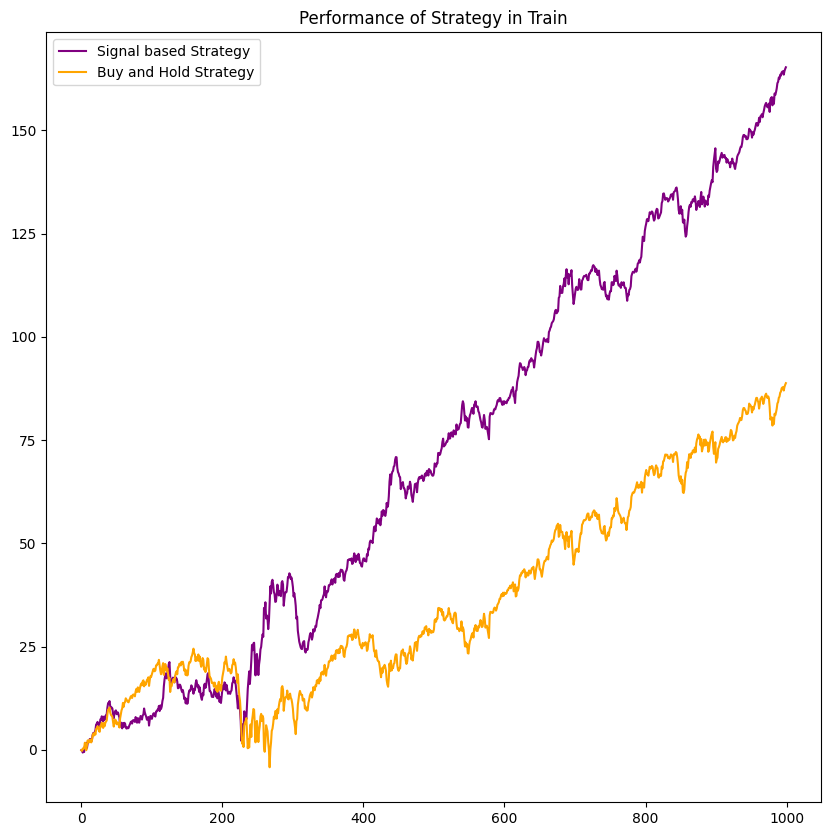

In [11]:
plt.figure(figsize=(10,10))
plt.title('Performance of Strategy in Train')
plt.plot(Train['Wealth'].values, color='purple',label='Signal based Strategy')
plt.plot(Train['spy'].cumsum().values,color='orange',label='Buy and Hold Strategy')
plt.legend()
plt.show()

In [12]:
# Test
Test['Order'] = [1 if sig>0 else -1 for sig in Test['PredictedY']]
Test['Profit'] = Test['spy'] * Test['Order']

Test['Wealth'] = Test['Profit'].cumsum()
print(f"Total profit made in Test: {Test['Profit'].sum()}")

Total profit made in Test: 52.890441999999865


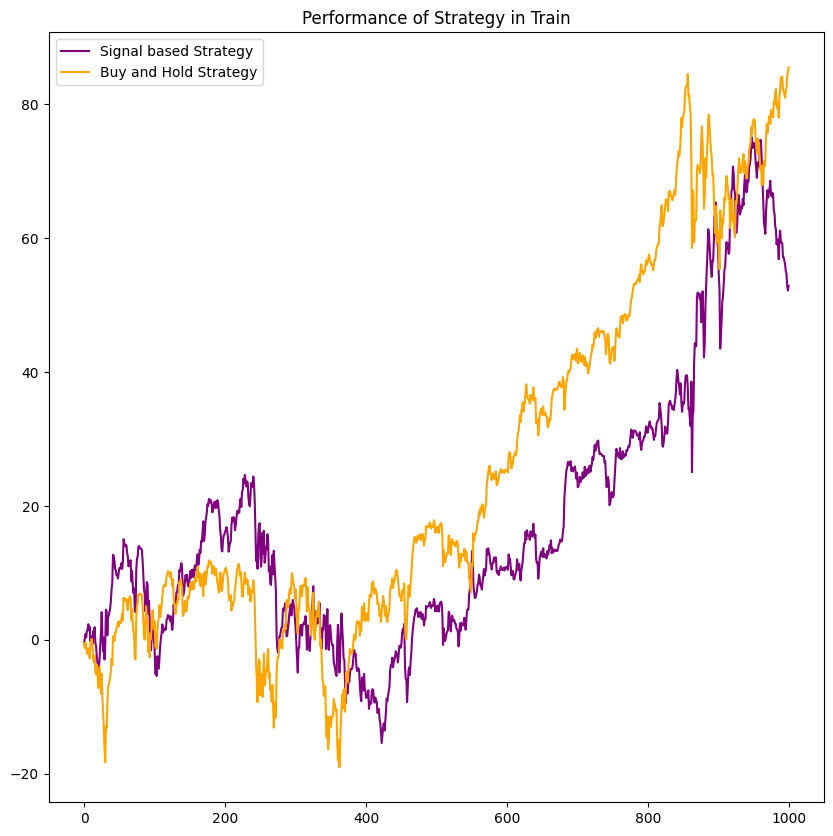

In [13]:
plt.figure(figsize=(10,10))
plt.title('Performance of Strategy in Train')
plt.plot(Test['Wealth'].values, color='purple',label='Signal based Strategy')
plt.plot(Test['spy'].cumsum().values,color='orange',label='Buy and Hold Strategy')
plt.legend()
plt.show()

### **Evaluation of model - Practical Standard**

##### We introduce 2 common practical standards - **Sharpe Ratio, Maximum Drawdown** to evaluate our model performance

In [14]:
Train['Wealth'] = Train['Wealth'] + Train.loc[Train.index[0], 'Price']
Test['Wealth'] = Test['Wealth'] + Test.loc[Test.index[0], 'Price']

In [16]:
# Sharpe Ratio on Train Data
Train['Return'] = np.log(Train['Wealth']) - np.log(Train['Wealth'].shift(1))
dailyr = Train['Return'].dropna()

print(f'Daily Sharpe Ratio is {dailyr.mean()/dailyr.std(ddof=1)}')
print(f'Yearly Sharpe Ratio is {(252**0.5)*dailyr.mean()/dailyr.std(ddof=1)}')

Daily Sharpe Ratio is 0.11466346581261085
Yearly Sharpe Ratio is 1.8202260900295502


In [17]:
# Sharpe Ratio in Test Data
Test['Return'] = np.log(Test['Wealth']) - np.log(Test['Wealth'].shift(1))
dailyr = Test['Return'].dropna()

print(f'Daily Sharpe Ratio is {dailyr.mean()/dailyr.std(ddof=1)}')
print(f'Yearly Sharpe Ratio is {(252**0.5)*dailyr.mean()/dailyr.std(ddof=1)}')

Daily Sharpe Ratio is 0.029844101871228844
Yearly Sharpe Ratio is 0.4737604299200935


In [18]:
# Maximum Drawdown in Train Data
Train['Peak'] = Train['Wealth'].cummax()
Train['Drawdown'] = (Train['Peak'] - Train['Wealth'])/Train['Peak']
print(f"Maximum Drawdown in Train is {Train['Drawdown'].max()}")

Maximum Drawdown in Train is 0.1427181114498669


In [19]:
# Maximum Drawdown in Test Data
Test['Peak'] = Test['Wealth'].cummax()
Test['Drawdown'] = (Test['Peak'] - Test['Wealth'])/Test['Peak']
print(f"Maximum Drawdown in Test is {Test['Drawdown'].max()}")

Maximum Drawdown in Test is 0.17728508860184677
